<a href="https://colab.research.google.com/github/Kafkasyahrial/data-science-2026/blob/main/Pertemuan9_KafkaSyahrial_%5B240401010045%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 9 - Aktivitas Hands-on: Prediksi Diagnosis
**Nama:** Kafka Syahrial Fauzan  
**Prodi:** Informatika - Universitas Siber Asia

Langkah 1: Load Dataset & Exploratory Data Analysis (EDA) Singkat

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset bawaan scikit-learn
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant (ganas), 1 = benign (jinak)

# Tampilkan informasi dasar data
print('Shape dataset:', X.shape)
print('\nDistribusi target (0: Ganas, 1: Jinak):')
print(pd.Series(y).value_counts(normalize=True).round(3))
print("\n5 Data Teratas:")
X.head()

Shape dataset: (569, 30)

Distribusi target (0: Ganas, 1: Jinak):
1    0.627
0    0.373
Name: proportion, dtype: float64

5 Data Teratas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Distribusi Target: value_counts(normalize=True) digunakan untuk melihat apakah terjadi ketidakseimbangan kelas (imbalanced data). Evaluasi akurasi bisa sangat menyesatkan jika perbandingan kelasnya terlampau ekstrem.

Langkah 2: Preprocessing Data (Train-Test Split & Scaling)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Membagi data menjadi 80% Train dan 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Standardisasi Fitur menggunakan StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Preprocessing selesai!")
print(f"Jumlah data training: {X_train.shape[0]}, Jumlah data testing: {X_test.shape[0]}")

Preprocessing selesai!
Jumlah data training: 455, Jumlah data testing: 114


StandardScaler (Feature Scaling): Mengubah fitur agar memiliki mean = 0 dan standar deviasi = 1. Langkah ini sangat penting bagi Logistic Regression untuk mempercepat konvergensi algoritma optimasinya. Sebaliknya, Decision Tree tidak membutuhkan scaling karena pembagian fiturnya (split) didasarkan pada ambang batas nilai individual, bukan jarak matematika antar-fitur.

Langkah 3: Melatih Model Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression

# 1. Inisialisasi dan fitting model pada data berskala (scaled)
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)

# 2. Prediksi kelas pada data test
y_pred_log = log_model.predict(X_test_s)

# 3. Ekstraksi fitur paling berpengaruh berdasarkan nilai absolut koefisien
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print("=== 5 Fitur Paling Berpengaruh (Logistic Regression) ===")
print(coef_df.head())

=== 5 Fitur Paling Berpengaruh (Logistic Regression) ===
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


Logistic Regression: Walaupun mengandung kata 'Regression', algoritma ini digunakan murni untuk klasifikasi. Algoritma ini memetakan kombinasi linear fitur ke fungsi Sigmoid , menghasilkan nilai probabilitas dengan rentang tak terbatas menjadi rentang $[0, 1]$.  

Langkah 4: Melatih Model Decision Tree

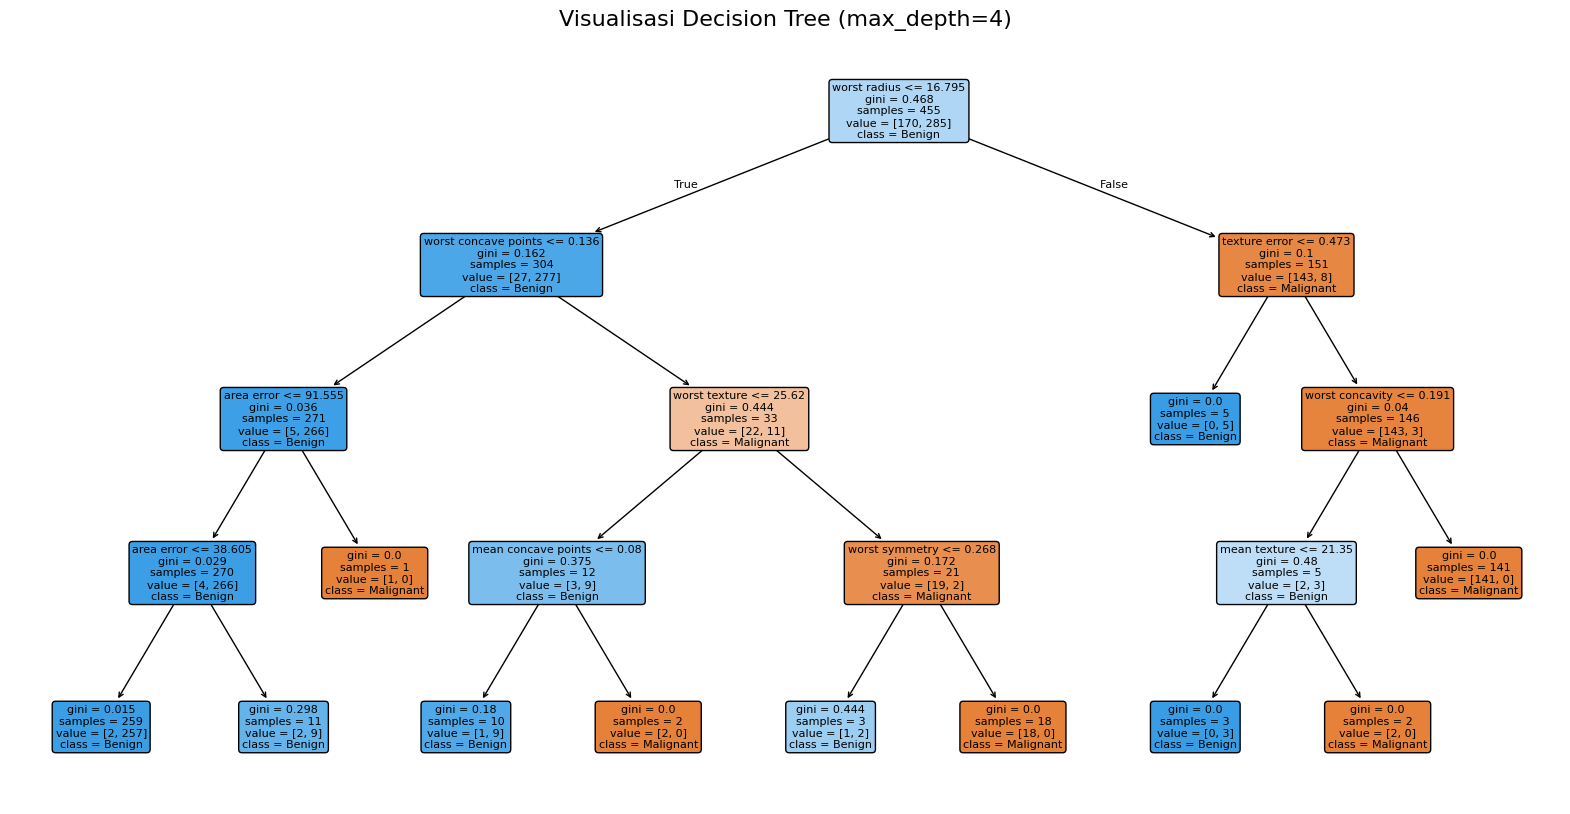

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Inisialisasi model dengan pembatasan kedalaman (max_depth=4) pada data asli
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# 2. Prediksi kelas
y_pred_tree = tree_model.predict(X_test)

# 3. Visualisasi pohon keputusan yang terbentuk
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, class_names=['Malignant', 'Benign'], filled=True, rounded=True)
plt.title("Visualisasi Decision Tree (max_depth=4)", fontsize=16)
plt.show()

Decision Tree: Berfungsi membuat aturan keputusan bertingkat (if-else) yang mudah diinterpretasikan. Secara default di scikit-learn, tingkat kemurnian node diukur menggunakan Gini Impurity karena komputasinya lebih cepat daripada Entropy.

Langkah 5: Evaluasi & Perbandingan Performa

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Loop untuk menghitung metrik performa masing-masing model secara komparatif
for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    print(f"\n==================== {name} ====================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.3f}")


==================== Logistic Regression ====================
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy  : 0.982
Precision : 0.986
Recall    : 0.986
F1-Score  : 0.986

==================== Decision Tree ====================
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy  : 0.939
Precision : 0.958
Recall    : 0.944
F1-Score  : 0.951


Confusion Matrix: Tabel kontingensi $2\times2$ yang memetakan kecocokan antara aktual vs prediksi (True Positive, True Negative, False Positive, False Negative).

Accuracy: Mengukur kedekatan akurasi prediksi benar secara global terhadap total populasi data.

Precision: Dari semua yang diprediksi Positif (Benign), berapa banyak yang benar-benar Positif? Berfokus meminimalkan False Positive.  

Recall (Sensitivity): Dari semua yang sebenarnya Positif, berapa banyak yang berhasil dideteksi oleh model? Berfokus meminimalkan False Negative.  

(Markdown)

### Pembahasan Hasil Evaluasi Model

1. **Mengapa Recall adalah Metrik Paling Kritis dalam Diagnosis Medis?**
   Dalam kasus kanker, kesalahan **False Negative (FN)** jauh lebih fatal daripada *False Positive (FP)*.

   **False Negative (Bahaya):** Pasien sebenarnya menderita kanker ganas (Malignant), tetapi model memprediksi tumor tersebut jinak (Benign). Akibatnya, pasien tidak mendapatkan penanganan medis segera dan kankernya bisa menyebar.

   **False Positive (Lebih Aman):** Pasien sebenarnya sehat/jinak, tetapi diprediksi mengidap kanker ganas. Pasien hanya akan menjalani tes konfirmasi lanjutan (skrining ulang), yang mana aman secara medis.
   Oleh karena itu, target utama pemodelan medis adalah mendapatkan nilai **Recall setinggi mungkin** mendekati 1.0 demi meminimalkan kasus kanker yang terlewat.

2. **Perbandingan Performa:**
   Secara umum pada dataset ini, **Logistic Regression** cenderung memberikan hasil Recall dan F1-Score yang sedikit lebih stabil dan tinggi dibandingkan Decision Tree tunggal dengan kedalaman terbatas `max_depth=4`.